# User Guide


---

## Introduction

The craceplot package provides a set of functions to create plots to visualize the configuration data generated by the configuration process implemented in the crace package.

The configuration process performed by crace will show at the end of the execution one or more configurations that are the best performing configurations found. This package provides a set of functions that allow to further assess the performance of these configurations and provides support to obtain insights about the details of the configuration process.


---

## Installation

### Install craceplot from Pip
```bash
pip install cplot
```

### Install craceplot from conda
```bash
conda install cplot
```

### Excuting crace
To use the methods provided by this package you must have completed crace log files from a single run. The folder including all log files object is defaultly saved with name `race_log` after each crace execution.

During the configuration procedure crace evaluates a lot candidate configurations (parameter settings) on different training instances, creating an algorithm performance data set we call the training data set. This information is thus, the data that crace had access to when configuring the target algorithm.

You can also enable the test evaluation option in crace, in which a set of elite configurations will be evaluated on a set of test instances after the training phase of crace is finished. Note that this option is not enabled by default and you must provide the test instances in order to enable it. The performance obtained in this evalaution is called the test data set. This evaluation helps assess the results of the configuration in a more “real” setup. For example, we can assess if the configuration process incurred in overtuning or if a type of instance was underrepresented in the training set.  For information about the crace setup we refer you to the crace package user guide.

Note: Before executing crace, consider enabling testing in crace.

Once crace is executed, you can load the crace log files in the Python console to check more details of this crace run.



---

## How to use

This is a basic example that shows how to use cplot:

```python
import cplot
```

Defaultly, crace log files are all stored in the folder named `race_log`.


### Load crace log files

You can load the data from the log files as follows:
```python
results, options = crace.start_cmdline(['-l', '/path/to/logs'])
```

If the path you provided including more than one crace run, one warning will be raised:
```
! ERROR: There was an error while reading crace options file:
!   The provided path including log folders from at least two crace runs, please specify the correct run you want to load.
```

If the path you provided including one crace run but not having all necessary log files, one warning will be raised:
```
! ERROR: There was an error while reading crace options file:
!   One crace run including all scenario, parameters, config, exps_fin log files must be provided.
```

When the crace run is loaded correctly, you can check the details of this execution via `results`.
```bash
results.all_elites     results.instances      results.scenario       results.test          
results.best_id        results.models         results.slice          results.training      
results.configurations results.options        results.state          results.version       
results.elites         results.parameters     results.summarise
```
Here are all objects results include:

- **all_elites**: all elite configuration IDs appear.
- **best_id**: final returned configuration ID by crace training phase.
- **elites**: elite configuration IDs at the end of crace trining phase.
- **configurations**: object Configurations.
- **instances**: object Instances, including training ang test instances.
- **models**: objec Models.
- **Options**: object CraceOptions.
- **parameters**: object Parameters of the target algorithm.
- **scenario**: a dict including all crace options and correspoding values.
- **slice**: a dataframe including information of each slice when updating models.
- **state**: a dict including the information loading from the provided crace run.
- **summarise**: object Summary for the information loading from the provided crace run.
- **test**: object TestResults for the executions on all test instances.
- **training**: object TrainResults for all experiments submitted, finished and discarded in the training phase.
- **version**: crace version of the provided run.

And here are all options in cplot:
```bash
options.arguments         options.man               options.showscale        
options.dataType          options.multiParameters   options.slice            
options.dpi               options.numConfigurations options.source           
options.drawMethod        options.options           options.statisticalTest  
options.fileName          options.outDir            options.title            
options.help              options.selConfigurations options.version          
options.keyParameter      options.showfliers       
options.logDir            options.showmeans  
```


---

## Visualizing crace configuration data

In the following, we provide two examples how the functions implemented in this package can be used to visualize the information generated by crace.
- example 1: ACOTSP {cite}`ACOTSP` - An Ant Colony Optimization framework with 11 parameters to be configured, which is implemented in C.
- example 2: Cats200 {cite}`cplex22.1` - from IBM ILOG CPLEX Optimization Studio is an optimizer to solve integer programming problems (MIP), very large linear programming problems using either primal or dual variants of the simplex method or barrier interior point method, convex and non-convex quadratic programming problems, and convex quadratically constrained problems (solved via second-order cone programming, or SOCP). It is implemented in C. Here we use CPLEX to solve MIP with 74 parameters to be configured on instances cats200.


In [4]:
import os
import sys

current_file = os.path.abspath('./')
CPLOT_HOME = os.path.dirname(os.path.dirname(current_file))
if CPLOT_HOME not in map(os.path.abspath, sys.path):
    sys.path.insert(0, os.path.abspath(CPLOT_HOME))

In [ ]:
import cplot

path_to_acotsp = os.path.join(CPLOT_HOME, 'cplot', '_inst', 'examples', 'acotsp')
path_to_cats200 = os.path.join(CPLOT_HOME, 'cplot', '_inst', 'examples', 'cats200')

In [ ]:
import crace

results1, options1 = cplot.run('-l', path_to_acotsp)
results2, options2 = cplot.run('-l', path_to_cats200)

### Configurations

Once crace is executed, the first thing you might want to do is to visualize how the best configurations look like.
Cplot provides several ways to draw plots for configurations, especially for their parameters.

#### function param_parallelcoord

The plot produced by `Parcoords` from model **plotly.graph_objects** can help you to both the distribution of the parameter values of a set of configurations and the common associations between these values. 

By default, the plot colors the lines using `slice_sampled` in which slice the configuration is sampled for all configurations in the racing. You can use the `colorby` argument to choose the parameter for coloring the lines. You can do this with the `param_parallelcoord` method:

In [4]:
cplot.param_parallelcoord(data=results1, options=options1)

#
# No parameters selected to draw plot, set to the default(random selected 10 parameters).
#    selected parameters: algorithm, alpha, ants, beta, dlb, elitistants, localsearch, nnls, q0, rho
#
# No keyParameter or sel_kvar provided, set colorscale as default.
#
# Mapping parameter type..
#  (WARNING: map values of parameter algorithm(c) for ploltting)
#  (WARNING: map values of parameter dlb(c) for ploltting)
#  (WARNING: map values of parameter localsearch(c) for ploltting)


You can draw more flexible parallel coord plots via providing parameters `configs`, `parameters`, `colorby`, `showscale`, `shownan`, `colorscale`. To check details for these arguments, call:

In [5]:
help(cplot.param_parallelcoord)

Help on function param_parallelcoord in module cplot._plots.parameters:

param_parallelcoord(data: 'CraceResults' = None, options: 'CplotOptions' = None, configs: "Union[Literal['all', 'final', 'elites'], list[int], None]" = 'all', parameters: 'Union[list[str], str, None]' = None, colorby: 'str' = None, slice: 'bool' = True, out_dir: 'str' = None, file_name: 'str' = None, tile: 'str' = None, _console: 'bool' = True, showscale: 'bool' = True, shownan: 'bool' = True, nbins: 'int' = 5, width: 'int' = 2560, height: 'int' = 1440, colorscale: 'str' = 'Tealrose')
    Entrance to call parallel coord in python console
    
    :param data: object CraceResults that must be provided.
    :param options: object CplotOptions that must be provided.
    :param configs: Optional. Selected configurations for plotting, higher priority than option numConfigurations/selConfigurations. Supported values are 'all', 'final', 'elites' or a list of configuration IDs. Default is 'all'.
    :param parameters: A l

In [6]:
cplot.param_parallelcoord(data=results1, options=options1, configs='final', colorby='configuration_id',
                          parameters=['algorithm', 'ants', 'beta', 'dlb', 'elitistants', 'localsearch'],
                          showscale=False, shownan=False, colorscale='YlGnBu')

#
# Parameter configuration_id is used for colorscale.
#
# Mapping parameter type..
#  (WARNING: map values of parameter algorithm(c) for ploltting)
#  (WARNING: map values of parameter dlb(c) for ploltting)
#  (WARNING: map values of parameter localsearch(c) for ploltting)


Note: when `shownan = False` but there are missing values in the selected configurations, the missing values would be automatically mapped to a legal value by Parcoords.

#### function param_sunburst

The plot produced by `Sunburst` from model **plotly.graph_objects** can create a pie plot that displays the values of all configurations sampled during the configuration process. This plot can be useful to display the tendencies in the sampling in a simple format. By default, the plot randomly selects 6 parameters for all sampled configurations. 

Here, numerical parameters domains are discretized to be shown in the plot. The size of each parameter value in the plot is dependent of the argument `textinfo`, which could be the count value (**value**) or percentage (**'percent root', 'percent entry', 'percent parent'**) of configurations having that value in the configurations.

You can use the `palette` argument to color the plot. You can do this with the `param_sunburst` method:

In [7]:
cplot.param_sunburst(data=results2, options=options2)

#
# No parameters selected to draw plot, set to the default(random selected 6 parameters).
#    selected parameters: barrier_crossover, mip_strategy_nodeselect, mip_strategy_presolvenode, network_pricing, simplex_limits_perturbation, simplex_tolerances_markowitz


You can draw more flexible plots via providing parameters `configs`, `parameters`, `palette`,  `shownan`, `branchvalues`, `count`, `insidetextorientation` and `textinfo`. To check details for these arguments, call:

In [8]:
help(cplot.param_sunburst)

Help on function param_sunburst in module cplot._plots.parameters:

param_sunburst(data: 'CraceResults' = None, options: 'CplotOptions' = None, configs: "Union[Literal['all', 'final', 'elites'], list[int], None]" = 'all', parameters: 'Union[list[str], str, None]' = None, _console: 'bool' = True, shownan: 'bool' = True, nbins: 'int' = 5, palette: 'str' = 'vlag', autosize: 'bool' = True, branchvalues: 'str' = 'total', maxdepth: 'int' = 3, count: 'str' = 'branches', insidetextorientation: 'str' = 'horizontal', textinfo: 'str' = 'label+value')
    Entrance to call sunburst in python console
    
    :param data: object CraceResults that must be provided.
    :param options: object CplotOptions that must be provided.
    :param configs: Optional. Selected configurations for plotting, higher priority than option numConfigurations/selConfigurations. 
                    | Union[Literal['all', 'final', 'elites'], list[int], None]='all'
    :param parameters: A list of parameter names selected 

In [9]:
cplot.param_sunburst(data=results1, options=options1, configs='elites',
                     parameters=['algorithm', 'q0', 'dlb', 'elitistants', 'nnls'],
                     shownan=False, palette='YlGnBu',
                     branchvalues='total',
                     count='leaves',
                     insidetextorientation='auto',
                     textinfo='label+percent parent')

#### function param_heatmap

The plot produced by `heatmap` from model **seaborn** can help you visualize the joint sampling frequency of two parameters. By default, this plot uses all configuration values on the selected parameters, you can also use argument `configs` to focus on the selected configurations. You can select two parameters using the `parameters` argument, or provide only one parameter to visualize its sampling frequency with `slice_sampled`, that when the configuration sampled.

You can use argument `colormap` to color the plot, and its available values could be checked using code:

```python
import matplotlib.pyplot as plt
plt.colormaps( )
```

You can plot heatmap with the `param_heatmap` method:


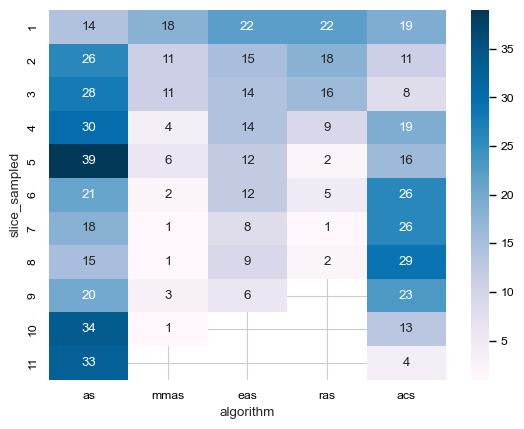

In [10]:
cplot.param_heatmap(data=results1, options=options1, parameters='algorithm')

You can draw more flexible heatmap plots via providing parameters `configs`, `parameters`, `colormap`,  `shownan` and `nbins`.
The argument `nbins` is used to split the domain of continouos paramters. To check details for these arguments, call:

In [11]:
help(cplot.param_heatmap)

Help on function param_heatmap in module cplot._plots.parameters:

param_heatmap(data: 'CraceResults' = None, options: 'CplotOptions' = None, configs: "Union[Literal['all', 'final', 'elites'], list[int], None]" = 'all', parameters: 'Union[list[str], str, None]' = None, _console: 'bool' = True, shownan: 'bool' = True, nbins: 'int' = 5, dpi: 'int' = 800, colormap: 'Optional[Union[str, list, Colormap]]' = 'PuBu', fmt: 'str' = 'g')
    Entrance to call heatmap in python console
    
    :param data: object CraceResults that must be provided.
    :param options: object CplotOptions that must be provided.
    :param configs: Optional. Selected configurations for plotting, higher priority than option numConfigurations/selConfigurations. 
                    | Union[Literal['all', 'final', 'elites'], list[int], None]='all'
    :param parameters: a list of parameter names selected for plotting, higher priority than option multiParameters.
    :param shownan: boolean used to plot including/exclu

#
# Mapping parameter type..
#  (WARNING: convert parameter q0(r) to categorical for plotting)
#  (WARNING: convert parameter rasrank(i) to categorical for plotting)


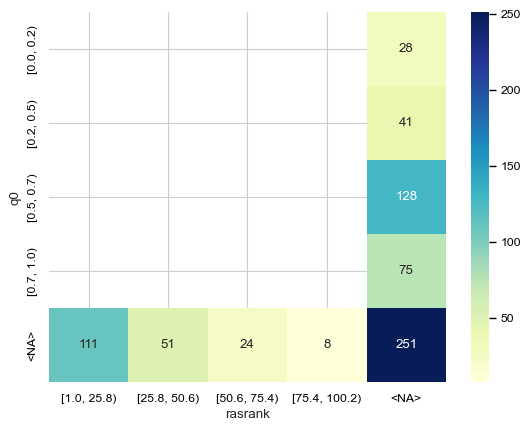

In [12]:
cplot.param_heatmap(data=results1, options=options1, 
                    parameters=['q0', 'rasrank'],
                    shownan=True, colormap='YlGnBu')

#### function param_boxplot

Function `param_boxplot` can help you visualize the distribution of selected parameter(s). By default, this plot uses all configuration values on the selected parameter(s) and map all value aspects to different slices. 

For categorical and continuous parameters, this function produces different visualizations: a normalized stacked bar chart for categorical parameters and a boxplot for continuous parameters, respectively.

You can use argument `monochrome` to enable or disable coloring the plot, and argument `palette` to provide an available string value for coloring.

You can plot with the `param_boxplot` method:

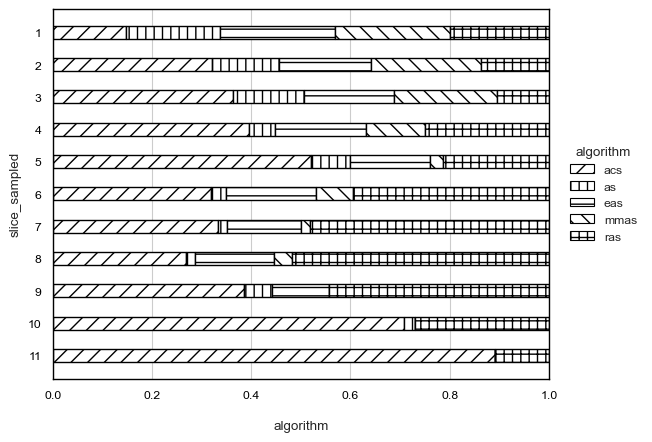

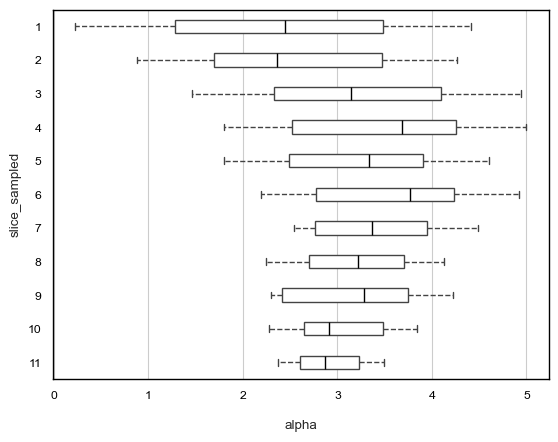

In [13]:
cplot.param_boxplot(data=results1, options=options1, parameters=['algorithm', 'alpha'])

In order to draw more flexible plots, you can provide parameters `configs`, `parameters`, `y`,  `shownan`, `showfliers`, `showmeans`, `palette` and `monochrome`. To check details for these arguments, call:

In [14]:
help(cplot.param_boxplot)

Help on function param_boxplot in module cplot._plots.parameters:

param_boxplot(data: 'CraceResults' = None, options: 'CplotOptions' = None, configs: "Union[Literal['all', 'final', 'elites'], list[int], None]" = 'all', parameters: 'Union[list[str], str, None]' = None, _console: 'bool' = True, shownan: 'bool' = True, nbins: 'int' = 5, showfliers: 'bool' = False, showmeans: 'bool' = False, dpi: 'int' = 800, y: 'str' = 'slice_sampled', palette: 'str' = 'vlag', fliersize: 'float' = 0.5, monochrome: 'bool' = True)
    Entrance to call boxplot in python console
    
    :param data: object CraceResults that must be provided.
    :param options: object CplotOptions that must be provided.
    :param configs: Optional. Selected configurations for plotting, higher priority than option numConfigurations/selConfigurations. 
                    | Union[Literal['all', 'final', 'elites'], list[int], None]
    :param parameters: A list of parameter names selected for plotting, higher priority than op

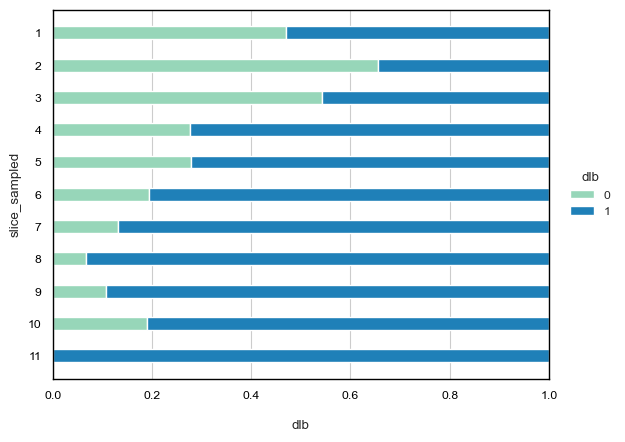

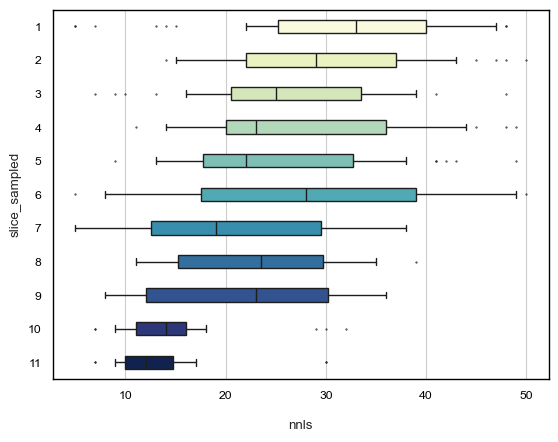

In [15]:
import random
max = results1.configurations.n_config
cplot.param_boxplot(data=results1, options=options1, parameters=['dlb', 'nnls'],
                    configs=random.sample(range(1, max), int(0.5*max)), # random selected a half of configuratioons
                    monochrome=False, shownan=False, palette='YlGnBu', 
                    showfliers=True)

#### function param_jointplot

Apart from the heatmap, joint plot is also provided to display the joint sampling frequency of two parameters and the distribution of each parameter. Similar to `param_heatmap`, by default, this joint plot uses all configuration values on the two selected categorical parameters, you can also use argument `configs` to draw plot on the selected configurations.

You must provide two continuous parameters using the `parameters` argument, and you can plot the joint plot by using code `param_jointplot`:


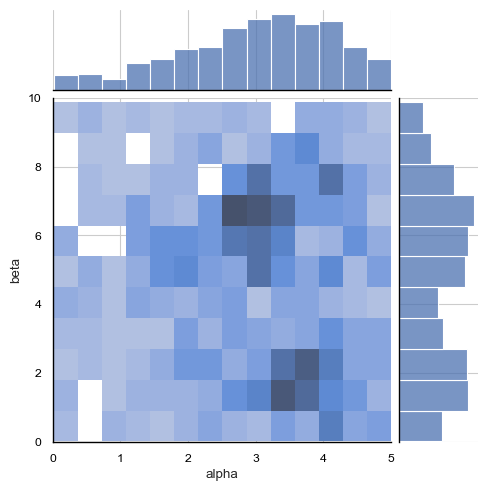

In [16]:
cplot.param_jointplot(data=results1, options=options1, parameters=['alpha', 'beta'])

Also, you can draw more flexible joint plots via providing parameters `hue`, `configs`, `parameters`, `palette`,  `shownan` and `kind`. To check details for these arguments, call:

In [17]:
help(cplot.param_jointplot)

Help on function param_jointplot in module cplot._plots.parameters:

param_jointplot(data: 'CraceResults' = None, options: 'CplotOptions' = None, configs: "Union[Literal['all', 'final', 'elites'], list[int], None]" = 'all', parameters: 'Union[list[str], str, None]' = None, slice: 'bool' = True, _console: 'bool' = True, shownan: 'bool' = True, nbins: 'int' = 5, dpi: 'int' = 800, kind: "Literal['scatter', 'kde', 'hist', 'hex', 'reg', 'resid']" = 'hist', space: 'float' = 0.1, ratio: 'int' = 4, palette: 'str' = 'vlag', hue: 'str' = None, height: 'int' = 5)
    Entrance to call pairplot in python console
    
    :param data: object CraceResults that must be provided.
    :param options: object CplotOptions that must be provided.
    :param configs: Optional. Selected configurations for plotting, higher priority than option numConfigurations/selConfigurations. 
                    | Union[Literal['all', 'final', 'elites'], list[int], None]='all'
    :param parameters: A list of parameter na

The argument `hue` is the third parameter provided for plotting the distributions of the selected two parameters on it.

The argument `kind` is type for the joint plot and its avaliable values are in **['scatter', 'kde', 'hist', 'hex', 'reg', 'resid']**.
Among these values, ['hex', 'reg', 'resid'] are not supported when argument `hue` is enabled.

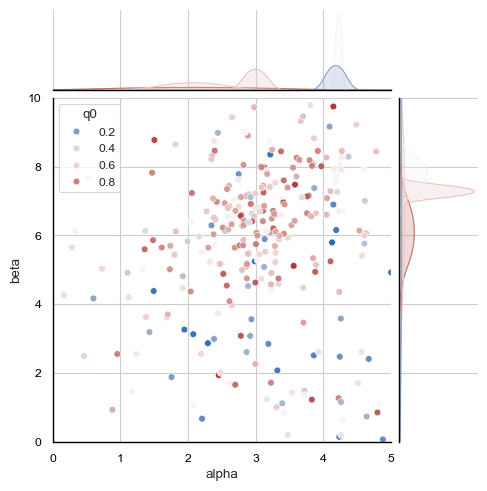

In [18]:
cplot.param_jointplot(data=results1, options=options1, parameters=['alpha', 'beta'],
                      hue='q0', 
                      kind='scatter', 
                      shownan=False)

#### function param_pairplot

Apart from the heatmap and joint plot, pair plot is also provided to display the pairwise relationships of provided parameters and the distribution of each parameter on the hue parameter. Similar to `param_jointplot`, by default, this plot uses all configuration values on the selected two categorical parameters, you can also use argument `configs` to focus on the selected configurations.

You must provide at least two continuous parameters using the `parameters` argument, and you can plot the pair plot by using code `param_pairplot`:


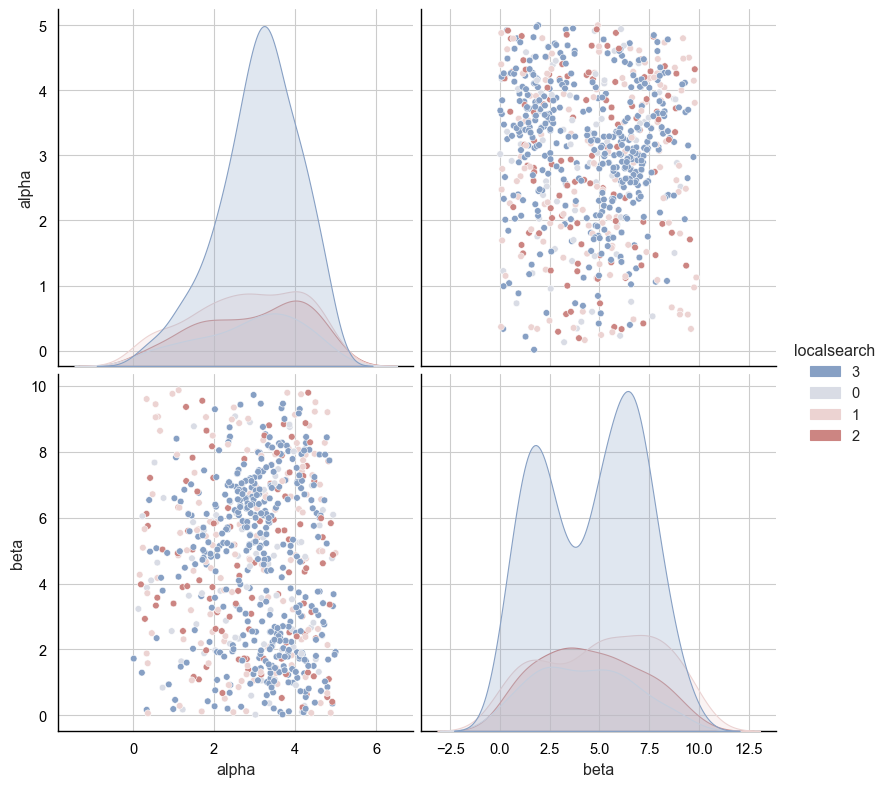

In [19]:
cplot.param_pairplot(data=results1, options=options1, parameters=['alpha', 'beta'], hue='localsearch')

To draw more flexible pair plots you can call this function via providing arguments `configs`, `parameters`, `hue`, `shownan`, `palette` and `kind`. To check details for these arguments, call:

In [20]:
help(cplot.param_pairplot)

Help on function param_pairplot in module cplot._plots.parameters:

param_pairplot(data: 'CraceResults' = None, options: 'CplotOptions' = None, configs: "Union[Literal['all', 'final', 'elites'], list[int], None]" = 'all', parameters: 'Union[list[str], str, None]' = None, slice: 'bool' = True, _console: 'bool' = True, shownan: 'bool' = True, dpi: 'int' = 800, hue: 'str' = None, palette: 'str' = 'vlag', kind: "Literal['auto', 'hist', 'kde', None]" = 'kde', height: 'int' = 4)
    Entrance to call pairplot in python console
    
    :param data: object CraceResults that must be provided.
    :param options: object CplotOptions that must be provided.
    :param configs: Optional. Selected configurations for plotting, higher priority than option numConfigurations/selConfigurations. 
                    | Union[Literal['all', 'final', 'elites'], list[int], None]='all'
    :param parameters: A list of parameter names selected for plotting, higher priority than option multiParameters.
    :para

The argument `hue` is the parameter provided to map plot aspects to different colors for the provided at least two parameters.

The argument `kind` is the type of plot for the diagonal subplots and its avaliable values are in **['auto', 'hist', 'kde', None]**. If 'auto', choose based on whether or not `hue` is used. 

The argument `shownan` enables or disables the inclusion of NaN values for the selected parameters.
In the case of mutually exclusive parameters, setting `shownan=False` results in empty intersections.

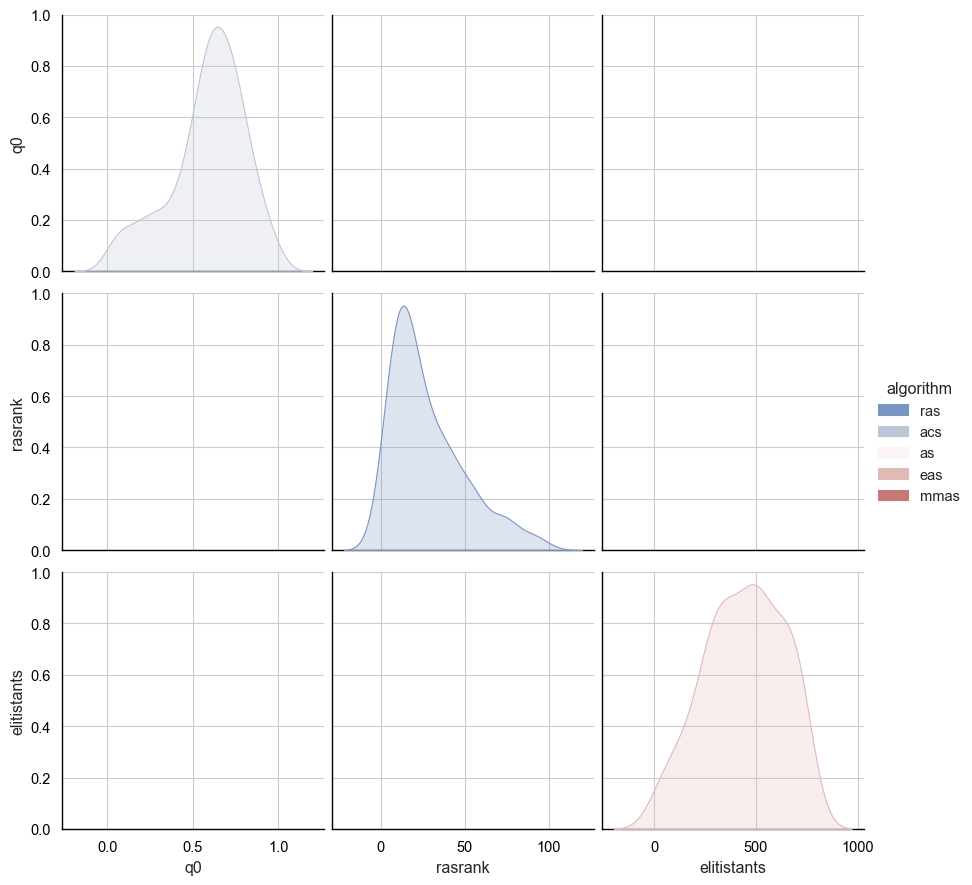

In [21]:
cplot.param_pairplot(data=results1, options=options1,
                     parameters=['q0', 'rasrank', 'elitistants'],
                     hue='algorithm',
                     kind='auto',
                     shownan=False,
                     height=3)

As shown in the above plot, when there is no joint sub-plots, it means all selected parameters are mutually exclusive.

#### function param_histplot

In some cases it might be interesting to have a look at the values sampled during the racing procedure as a distribution. Such plot shows the areas in the parameter space where **crace** detected a high performance. A general overview of the distribution of sampled parameters values can be obtained with the param_histplot which generates frequency and density plots for the sampled values of selected parameters.

The plot produced by `histplot` from model **seaborn**, and by default, the plot randomly selects 6 parameters from all sampled configurations. 

#
# No parameters selected to draw plot, set to the default(random selected 8 parameters).
#    selected parameters: alpha, ants, dlb, elitistants, localsearch, nnls, q0, rho


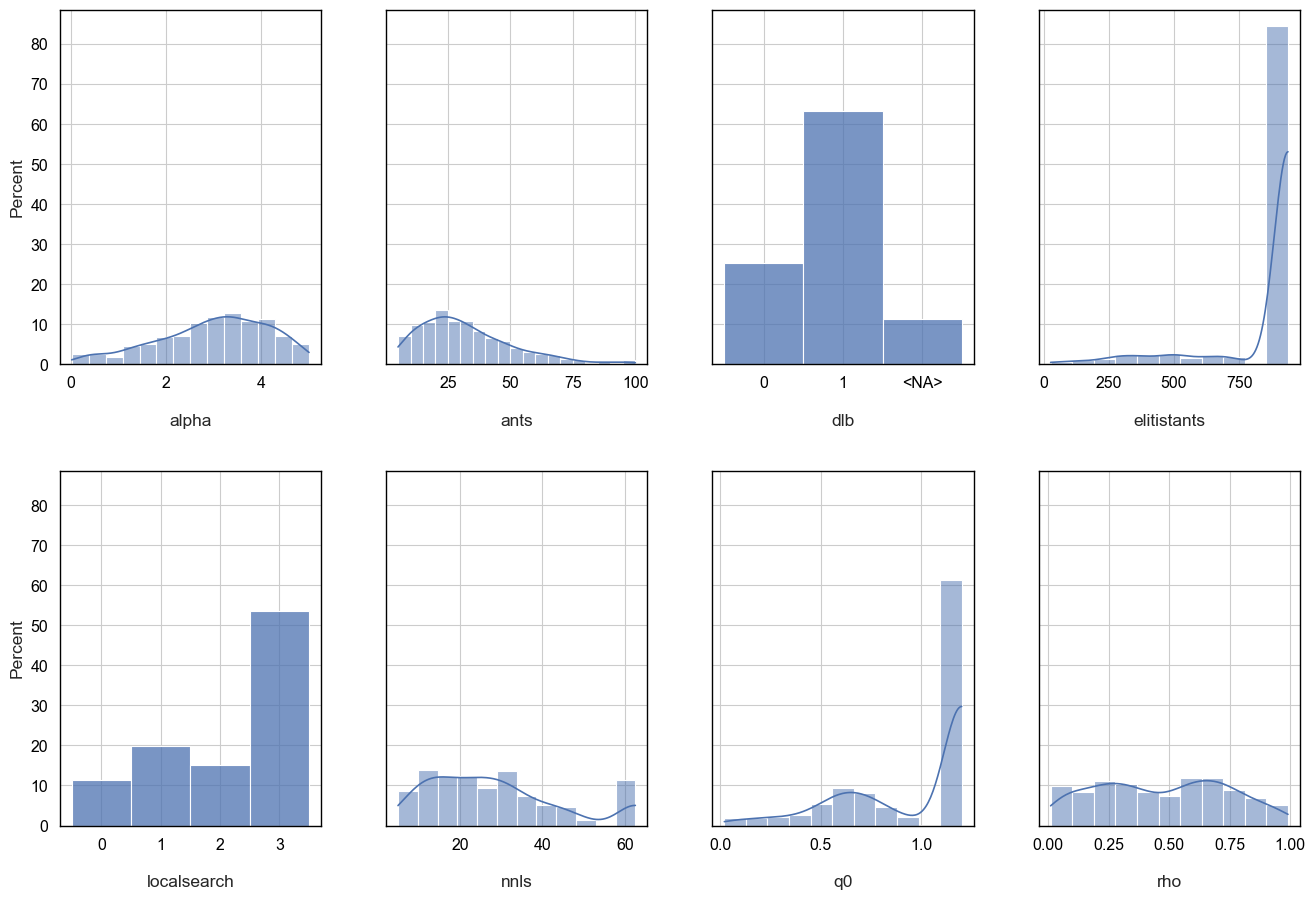

In [22]:
cplot.param_histplot(data=results1, options=options1)

In order to draw more flexible plots for the distribution of selected parameters, you can provide arguments `configs`, `parameters`, `shownan`, `stat`, `density`, `sharex` and `sharey`. 

`stat` is a string from provided values ['count', 'frequency', 'probability', 'percent', 'density'] for the type/shape of plots and its default value is 'percent'.

To check details for these arguments, call:

In [23]:
help(cplot.param_histplot)

Help on function param_histplot in module cplot._plots.parameters:

param_histplot(data: 'CraceResults' = None, options: 'CplotOptions' = None, configs: "Union[Literal['all', 'final', 'elites'], list[int], None]" = 'all', parameters: 'Union[list[str], str, None]' = None, slice: 'bool' = False, _console: 'bool' = True, shownan: 'bool' = True, nbins: 'int' = 5, dpi: 'int' = 1600, stat: "Literal['count', 'frequency', 'probability', 'percent', 'density']" = 'percent', density: 'bool' = False, sharex: 'bool' = False, sharey: 'bool' = True)
    Entrance to call histplot in python console
    
    :param data: object CraceResults that must be provided.
    :param options: object CplotOptions that must be provided.
    :param configs: Optional. Selected configurations for plotting, higher priority than option numConfigurations/selConfigurations. 
                    | Union[Literal['all', 'final', 'elites'], list[int], None]
    :param parameters: A list of parameter names selected for plottin

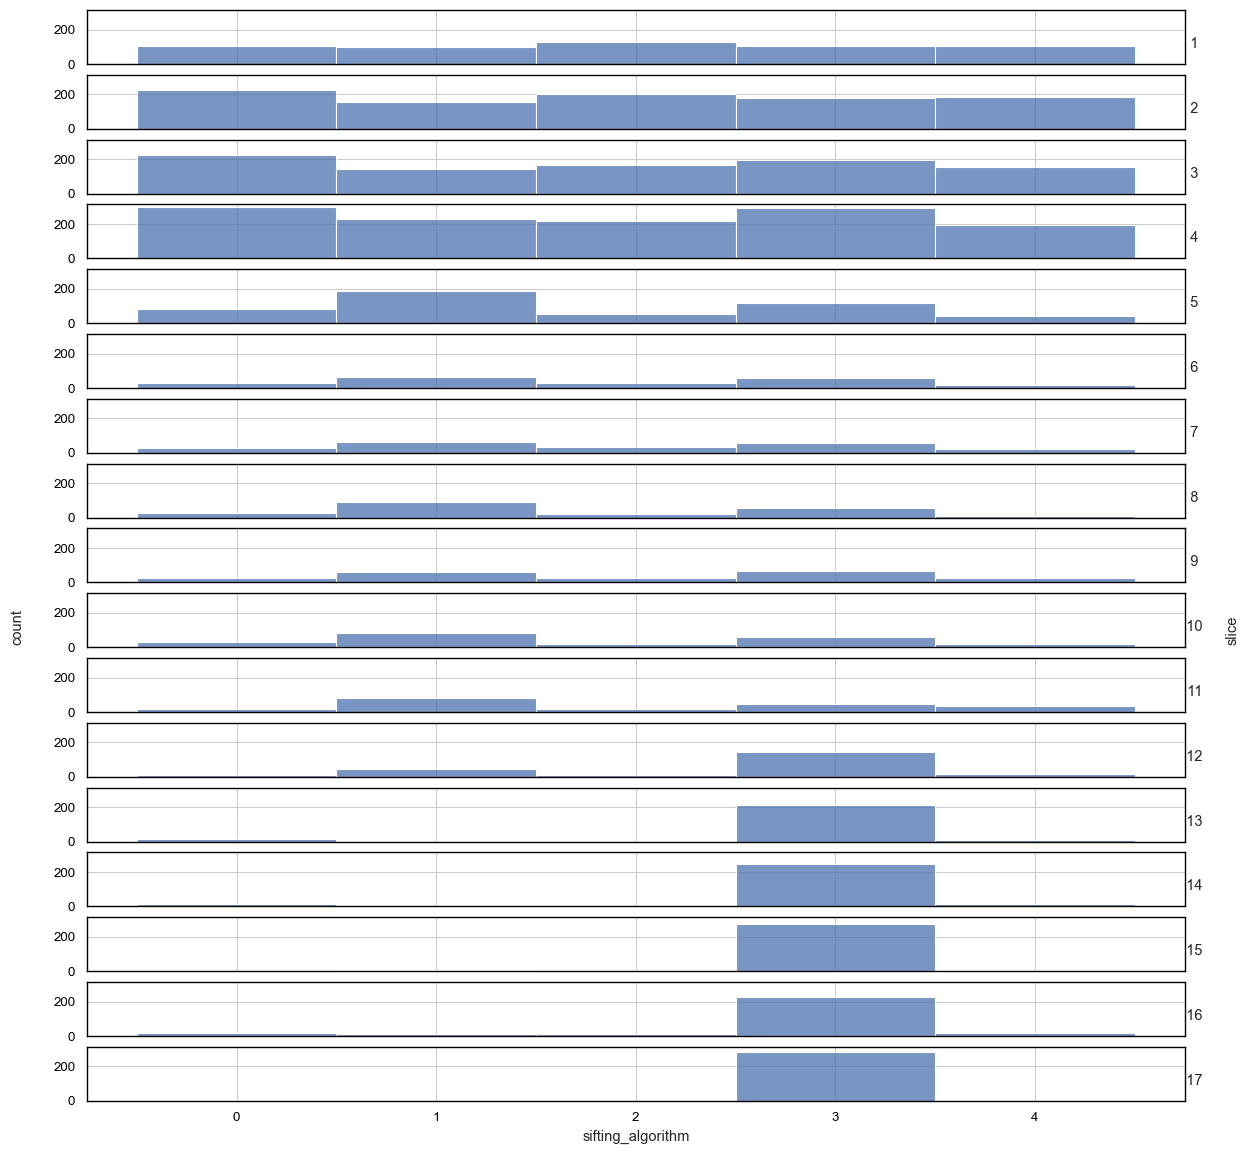

In [24]:
cplot.param_histplot(data=results2, options=options2,
                     configs='all',
                     parameters='sifting_algorithm',
                     slice=True,
                     stat='count',
                     density=True,)

### Experiments


#
# Adjusted p-values of the last two elite configurations:
        495     588
495  1.0000  0.3503
588  0.3503  1.0000
588 vs. 495: Wilcoxon test (paired samples) with Benjamini-Hochberg correction, P_val:3.503e-01 Stat=6.100e+02


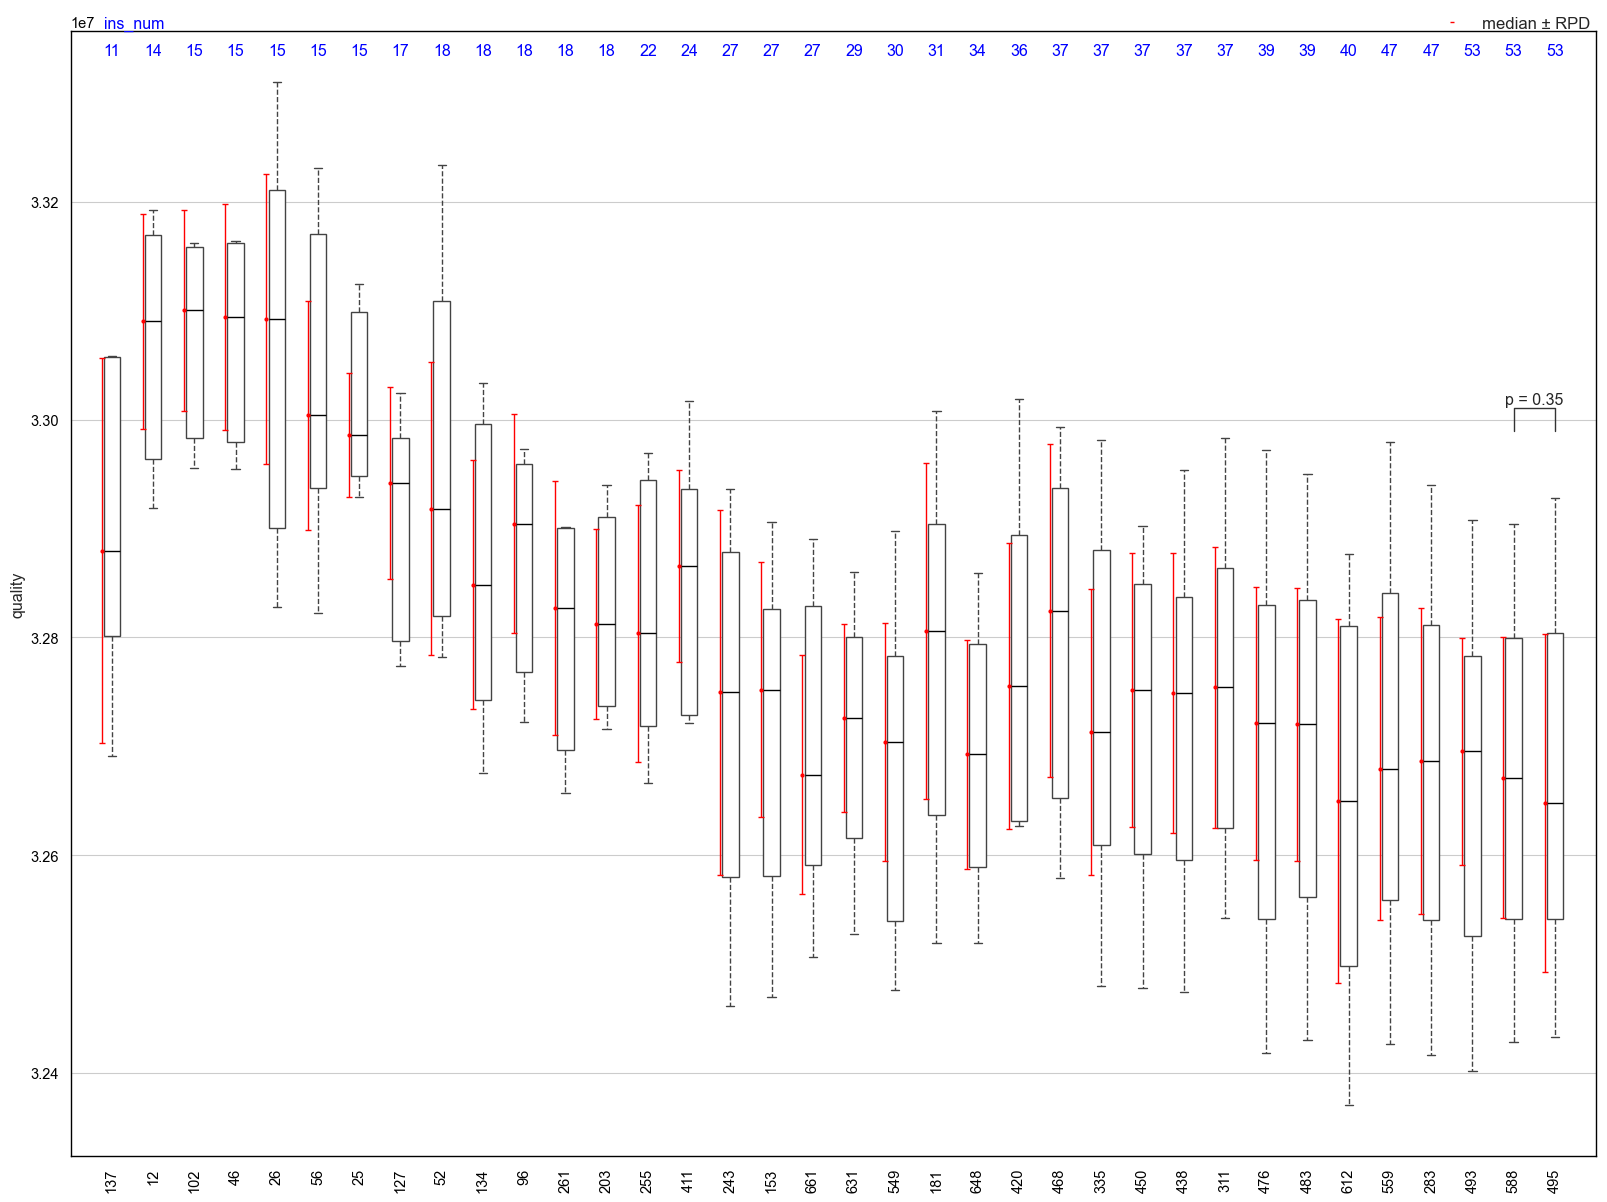

In [25]:
cplot.qual_boxplot(data=results1, options=options1, source='training', num='all')

In [ ]:
fig = cplot.qual_heatmap(data=results1, options=options1, source='training', return_fig=True)

from IPython.display import HTML, display
import plotly.io as pio

html = pio.to_html(fig, full_html=False,
    include_plotlyjs="https://unpkg.com/plotly.js-dist-min@latest/plotly.min.js",
)

display(HTML(html))


In [ ]:
fig = cplot.qual_heatmap(data=results2, options=options2, source='training', return_fig=True)

from IPython.display import HTML, display
import plotly.io as pio

html = pio.to_html(fig, full_html=False,
    include_plotlyjs="https://unpkg.com/plotly.js-dist-min@latest/plotly.min.js",
)

display(HTML(html))